In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().parent

RAW_DIR = (
    PROJECT_ROOT / "data" / "raw" / "chbmit"
)

PREPROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "chbmit"
    / "preprocessing_v1"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "preprocessing"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [3]:
manifest = pd.read_csv(
    PROJECT_ROOT
    / "metadata"
    / "preprocessing"
    / "chbmit_preprocessing_manifest.csv"
)

manifest.shape

(654, 37)

# Compare a file before and after

In [4]:
selected = manifest.iloc[0]

raw_before = mne.io.read_raw_edf(
    PROJECT_ROOT / selected["input_edf_path"],
    preload=False,
    verbose="ERROR",
)

raw_after = mne.io.read_raw_fif(
    PROJECT_ROOT / selected["output_fif_path"],
    preload=False,
    verbose="ERROR",
)

print("Before:", raw_before)
print("After:", raw_after)
print("After channels:", raw_after.ch_names)

Before: <RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~22 KiB, data not loaded>
After: <Raw | chb01_01_preproc-v1_raw.fif, 17 x 921600 (3600.0 s), ~19 KiB, data not loaded>
After channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FZ-CZ', 'CZ-PZ', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'P8-O2']


In [5]:
assert len(raw_after.ch_names) == 17
assert raw_after.info["sfreq"] == 256

# PSD comparison

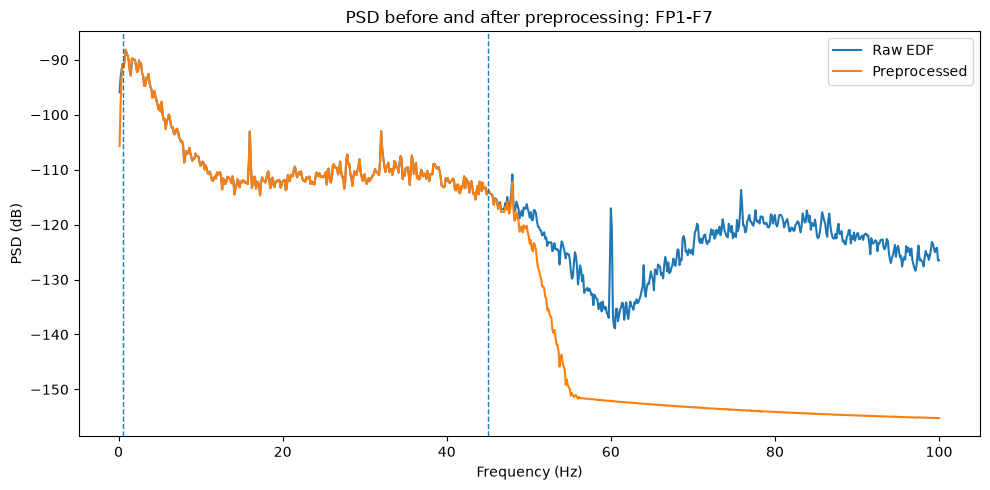

In [6]:
channel = raw_after.ch_names[0]

spectrum_before = raw_before.compute_psd(
    method="welch",
    fmin=0.1,
    fmax=100,
    picks=[channel],
    tmin=60,
    tmax=300,
    remove_dc=True,
    verbose="ERROR",
)

spectrum_after = raw_after.compute_psd(
    method="welch",
    fmin=0.1,
    fmax=100,
    picks=[channel],
    tmin=60,
    tmax=300,
    remove_dc=True,
    verbose="ERROR",
)

frequencies_before = spectrum_before.freqs
psd_before = spectrum_before.get_data()[0]

frequencies_after = spectrum_after.freqs
psd_after = spectrum_after.get_data()[0]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    frequencies_before,
    10 * np.log10(psd_before),
    label="Raw EDF",
)

ax.plot(
    frequencies_after,
    10 * np.log10(psd_after),
    label="Preprocessed",
)

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    45,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (dB)")
ax.set_title(
    f"PSD before and after preprocessing: {channel}"
)
ax.legend()

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "psd_before_after.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

`Raw.compute_psd()` is the official MNE method for calculating the Raw spectrum.

# Check Annotation Alignment
A file has a seizure:

In [7]:
seizure_record = manifest.loc[
    manifest[
        "after_observed_ictal_annotation_count"
    ] > 0
].iloc[0]

raw_after = mne.io.read_raw_fif(
    PROJECT_ROOT
    / seizure_record["output_fif_path"],
    preload=False,
    verbose="ERROR",
)

raw_after.annotations

<Annotations | 1 segment: ictal (1)>

# Show five seconds before onset:

In [8]:
ictal_mask = (
    raw_after.annotations.description
    == "ictal"
)

first_onset = float(
    raw_after.annotations.onset[
        ictal_mask
    ][0]
)

raw_after.plot(
    start=max(0, first_onset - 5),
    duration=20,
    n_channels=17,
    scalings="auto",
)

Using qt as 2D backend.


# Statistical comparison of input and output

In [9]:
manifest[
    [
        "input_sampling_rate_hz",
        "output_sampling_rate_hz",
        "input_duration_seconds",
        "output_duration_seconds",
        "input_n_times",
        "output_n_times",
        "input_channel_count",
        "output_channel_count",
    ]
].describe()

,input_sampling_rate_hz,output_sampling_rate_hz,input_duration_seconds,output_duration_seconds,input_n_times,output_n_times,input_channel_count,output_channel_count
count,654.0,654.0,654.000000,654.000000,6.540000e+02,6.540000e+02,654.000000,654.0
mean,256.0,256.0,4969.324159,4969.324159,1.272147e+06,1.272147e+06,26.128440,17.0
std,0.0,0.0,3440.347037,3440.347037,8.807288e+05,8.807288e+05,3.869069,0.0
min,256.0,256.0,600.000000,600.000000,1.536000e+05,1.536000e+05,22.000000,17.0
25%,256.0,256.0,3600.000000,3600.000000,9.216000e+05,9.216000e+05,23.000000,17.0
50%,256.0,256.0,3600.000000,3600.000000,9.216000e+05,9.216000e+05,24.500000,17.0
75%,256.0,256.0,3600.000000,3600.000000,9.216000e+05,9.216000e+05,28.000000,17.0
max,256.0,256.0,14427.000000,14427.000000,3.693312e+06,3.693312e+06,38.000000,17.0


Because resampling is disabled, the number of samples should not change.

# Edge Artifact Check
For at least five recordings, we check:
* The beginning of the file;
* The middle of the file;
* The end of the file;
* Around the onset seizure;
* Around the offset seizure.

In [11]:
raw_after.plot(
    start=0,
    duration=20,
    n_channels=17,
    scalings="auto",
)

In [12]:
duration = (
    raw_after.n_times
    / raw_after.info["sfreq"]
)

raw_after.plot(
    start=max(0, duration - 20),
    duration=20,
    n_channels=17,
    scalings="auto",
)

MNE's reflective padding for FIR filtering helps reduce the edge effect, but image inspection is still required. MNE supports padding options in filtering, including reflect_limited.